In [1]:
import os
import sys
import logging
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from tqdm.auto import tqdm

sys.path.insert(0, "../src")  # make validation/src importable
from build_amy_epw import AMYEPWBuilder

logging.basicConfig(level=logging.INFO, format="%(levelname)s  %(message)s")

load_dotenv("../.env")
NREL_API_KEY = os.environ["NREL_API_KEY"]
NREL_EMAIL   = os.environ["NREL_EMAIL"]

YEAR    = 2023
OUT_DIR = Path("../src/data/weather")
OUT_DIR.mkdir(parents=True, exist_ok=True)

d:\amber_ob\OBGeneration\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load station_ids from quality-filtered valid sites



In [2]:
VALID_STATION_IDS_PATH = Path("../src/data/metadata/rbsa3_2022_station_ids.csv")

if not VALID_STATION_IDS_PATH.exists():
    raise FileNotFoundError(
        f"{VALID_STATION_IDS_PATH} does not exist. Run the site coverage map cell in proc.ipynb first."
    )


def normalize_station_id(station_id):
    station_id = str(station_id).strip()
    if "-" not in station_id:
        return station_id
    usaf, wban = station_id.split("-", 1)
    return f"{usaf}-{wban.zfill(5)}"

valid_station_ids_raw = (
    pd.read_csv(VALID_STATION_IDS_PATH, dtype={"station_id": str})["station_id"]
    .dropna()
    .unique()
)
valid_station_ids = pd.Index(valid_station_ids_raw).map(normalize_station_id).unique()
station_id_normalization = (
    pd.DataFrame({"station_id_raw": valid_station_ids_raw})
    .assign(station_id=lambda df: df["station_id_raw"].map(normalize_station_id))
)

print(f"Loaded {len(valid_station_ids)} unique station IDs from {VALID_STATION_IDS_PATH}")
print(valid_station_ids)

Loaded 36 unique station IDs from ..\src\data\metadata\rbsa3_2022_station_ids.csv
Index(['720322-04129', '720734-00264', '726810-24131', '726813-94195',
       '726836-04201', '726881-94273', '726920-24230', '726930-24221',
       '726945-24202', '726959-94281', '726980-24229', '726985-24242',
       '726986-94261', '727834-24136', '727845-24163', '727846-24160',
       '727850-24157', '727855-24114', '727856-94176', '727870-94119',
       '727873-99999', '727884-99999', '727918-94298', '727923-94225',
       '727924-24223', '727930-24233', '727935-24234', '727937-24222',
       '727938-94274', '727945-04205', '742060-24207', '742071-24201',
       '994025-99999', '994048-99999', '994350-99999', '999999-04136'],
      dtype='str')


## Build DDY files from the nearest Climate.OneBuilding TMYx package

For EnergyPlus sizing, use the vetted design-day file bundled with the nearest TMYx weather ZIP instead of deriving DDY data from the AMY EPW. This cell resolves each valid WBAN station ID to NOAA ISD coordinates, finds the closest USA TMYx location from Climate.OneBuilding, downloads the ZIP, and extracts the included `.ddy` file next to the AMY `.epw`.

In [3]:
import re
import zipfile
from urllib.parse import urljoin, urlparse

import numpy as np
import requests

TMYX_USA_XLSX_URL = "https://climate.onebuilding.org/sources/Region4_USA_TMYx_EPW_Processing_locations.xlsx"
ISD_HISTORY_URL = "https://www.ncei.noaa.gov/pub/data/noaa/isd-history.csv"
TMYX_BASE_URL = "https://climate.onebuilding.org/"
DDY_OUT_DIR = OUT_DIR
TMYX_CACHE_DIR = OUT_DIR / "tmyx_cache"
DDY_MATCH_SUMMARY_PATH = OUT_DIR / "tmyx_ddy_match_summary.csv"
TMYX_CACHE_DIR.mkdir(parents=True, exist_ok=True)


def clean_col_name(value):
    return re.sub(r"[^a-z0-9]+", "_", str(value).strip().lower()).strip("_")


def find_column(columns, candidates):
    normalized = {clean_col_name(col): col for col in columns}
    for candidate in candidates:
        key = clean_col_name(candidate)
        if key in normalized:
            return normalized[key]
    for col in columns:
        key = clean_col_name(col)
        if any(clean_col_name(candidate) in key for candidate in candidates):
            return col
    return None


def normalize_wban(value):
    text = str(value).strip()
    if "-" in text:
        text = text.split("-")[-1]
    text = re.sub(r"\D", "", text)
    return text.zfill(5) if text else pd.NA


def normalize_zip_url(value):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip()
    if not text or ".zip" not in text.lower():
        return pd.NA
    match = re.search(r"https?://[^\s,;]+?\.zip", text, flags=re.IGNORECASE)
    if match:
        return match.group(0)
    match = re.search(r"[^\s,;]+?\.zip", text, flags=re.IGNORECASE)
    if match:
        return urljoin(TMYX_BASE_URL, match.group(0))
    return pd.NA


def haversine_km(lat1, lon1, lat2, lon2):
    radius_km = 6371.0088
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(np.asarray(lat2, dtype=float))
    lon2 = np.radians(np.asarray(lon2, dtype=float))
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * radius_km * np.arcsin(np.sqrt(a))


print("Loading Climate.OneBuilding USA TMYx catalog...")
tmyx_catalog = pd.read_excel(TMYX_USA_XLSX_URL)
tmyx_catalog.columns = [str(col).strip() for col in tmyx_catalog.columns]

lat_col = find_column(tmyx_catalog.columns, ["latitude", "lat"])
lon_col = find_column(tmyx_catalog.columns, ["longitude", "lon", "long"])
name_col = find_column(tmyx_catalog.columns, ["location", "name", "station", "city"])

zip_col = None
for col in tmyx_catalog.columns:
    sample = tmyx_catalog[col].dropna().astype(str).head(200)
    if sample.str.contains(r"\.zip", case=False, regex=True).any():
        zip_col = col
        break

if lat_col is None or lon_col is None or zip_col is None:
    raise ValueError(
        "Could not identify latitude, longitude, and ZIP URL columns in the TMYx catalog. "
        f"Columns found: {list(tmyx_catalog.columns)}"
    )

tmyx_catalog = tmyx_catalog.copy()
tmyx_catalog["tmyx_lat"] = pd.to_numeric(tmyx_catalog[lat_col], errors="coerce")
tmyx_catalog["tmyx_lon"] = pd.to_numeric(tmyx_catalog[lon_col], errors="coerce")
tmyx_catalog["tmyx_zip_url"] = tmyx_catalog[zip_col].map(normalize_zip_url)
tmyx_catalog["tmyx_name"] = tmyx_catalog[name_col].astype(str) if name_col else ""
tmyx_catalog = tmyx_catalog.dropna(subset=["tmyx_lat", "tmyx_lon", "tmyx_zip_url"]).reset_index(drop=True)
print(f"Loaded {len(tmyx_catalog):,} usable USA TMYx locations")

print("Loading NOAA ISD station coordinates...")
isd = pd.read_csv(ISD_HISTORY_URL, dtype=str)
isd.columns = [str(col).strip().upper() for col in isd.columns]
isd["WBAN"] = isd["WBAN"].map(normalize_wban)
isd["station_lat"] = pd.to_numeric(isd["LAT"], errors="coerce")
isd["station_lon"] = pd.to_numeric(isd["LON"], errors="coerce")
isd["end_sort"] = pd.to_numeric(isd.get("END", pd.Series(index=isd.index)), errors="coerce").fillna(0)
isd_coords = (
    isd.dropna(subset=["WBAN", "station_lat", "station_lon"])
    .sort_values(["WBAN", "end_sort"], ascending=[True, False])
    .drop_duplicates("WBAN")
    [["WBAN", "station_lat", "station_lon"]]
)

station_coords = pd.DataFrame({"station_id": pd.Index(valid_station_ids).astype(str)})
station_coords["wban"] = station_coords["station_id"].map(normalize_wban)
station_coords = station_coords.merge(isd_coords, left_on="wban", right_on="WBAN", how="left")

tmyx_header_lines = {}
records = []
for row in station_coords.itertuples(index=False):
    station_id = row.station_id
    ddy_path = DDY_OUT_DIR / f"{station_id}.ddy"

    if pd.isna(row.station_lat) or pd.isna(row.station_lon):
        records.append({
            "station_id": station_id,
            "station_lat": row.station_lat,
            "station_lon": row.station_lon,
            "status": "missing_noaa_isd_coordinates",
        })
        continue

    distances = haversine_km(row.station_lat, row.station_lon, tmyx_catalog["tmyx_lat"], tmyx_catalog["tmyx_lon"])
    nearest_idx = int(np.nanargmin(distances))
    nearest = tmyx_catalog.iloc[nearest_idx]
    zip_url = nearest["tmyx_zip_url"]
    zip_name = Path(urlparse(zip_url).path).name
    zip_path = TMYX_CACHE_DIR / zip_name

    try:
        if not zip_path.exists():
            response = requests.get(zip_url, timeout=90)
            response.raise_for_status()
            zip_path.write_bytes(response.content)

        with zipfile.ZipFile(zip_path) as zf:
            ddy_members = [name for name in zf.namelist() if name.lower().endswith(".ddy")]
            if not ddy_members:
                raise FileNotFoundError(f"No .ddy file found in {zip_name}")
            ashrae_members = [name for name in ddy_members if "ashrae" in name.lower()]
            ddy_member = ashrae_members[0] if ashrae_members else ddy_members[0]
            ddy_path.write_bytes(zf.read(ddy_member))

            epw_members = [name for name in zf.namelist() if name.lower().endswith(".epw")]
            if epw_members:
                epw_text = zf.read(epw_members[0]).decode("utf-8", errors="replace")
                for ln in epw_text.splitlines():
                    for prefix in ("DESIGN CONDITIONS", "TYPICAL/EXTREME PERIODS", "GROUND TEMPERATURES"):
                        if ln.startswith(prefix):
                            tmyx_header_lines.setdefault(station_id, {})[prefix] = ln

        status = "saved"
        error = ""
    except Exception as exc:
        status = "failed"
        error = str(exc)
        ddy_member = pd.NA

    records.append({
        "station_id": station_id,
        "station_lat": row.station_lat,
        "station_lon": row.station_lon,
        "tmyx_name": nearest.get("tmyx_name", ""),
        "tmyx_lat": nearest["tmyx_lat"],
        "tmyx_lon": nearest["tmyx_lon"],
        "distance_km": float(distances[nearest_idx]),
        "tmyx_zip_url": zip_url,
        "tmyx_zip_path": str(zip_path),
        "ddy_member": ddy_member,
        "ddy_path": str(ddy_path) if status == "saved" else "",
        "status": status,
        "error": error,
    })

tmyx_ddy_match_summary = pd.DataFrame(records)
tmyx_ddy_match_summary.to_csv(DDY_MATCH_SUMMARY_PATH, index=False)
print(f"Saved DDY match summary to {DDY_MATCH_SUMMARY_PATH}")
print(tmyx_ddy_match_summary["status"].value_counts(dropna=False))
display(tmyx_ddy_match_summary.sort_values(["status", "distance_km"], na_position="last"))

Loading Climate.OneBuilding USA TMYx catalog...
Loaded 13,356 usable USA TMYx locations
Loading NOAA ISD station coordinates...
Saved DDY match summary to ..\src\data\weather\tmyx_ddy_match_summary.csv
status
saved    36
Name: count, dtype: int64


,station_id,station_lat,station_lon,tmyx_name,tmyx_lat,tmyx_lon,distance_km,tmyx_zip_url,tmyx_zip_path,ddy_member,ddy_path,status,error
0,720322-04129,48.299,-116.560,Sandpoint.AP,48.2990,-116.5600,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_ID_Sandpoin...,USA_ID_Sandpoint.AP.720322_TMYx.2004-2018.ddy,..\src\data\weather\720322-04129.ddy,saved,
1,720734-00264,43.581,-116.523,Nampa.Muni.AP,43.5810,-116.5230,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_ID_Nampa.Mu...,USA_ID_Nampa.Muni.AP.720734_TMYx.2004-2018.ddy,..\src\data\weather\720734-00264.ddy,saved,
2,726810-24131,43.567,-116.241,Boise.AP-Gowen.Field.ANGB,43.5670,-116.2410,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_ID_Boise.AP...,USA_ID_Boise.AP-Gowen.Field.ANGB.726810_TMYx.2...,..\src\data\weather\726810-24131.ddy,saved,
3,726813-94195,43.650,-116.633,Caldwell.Indl.AP,43.6500,-116.6330,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_ID_Caldwell...,USA_ID_Caldwell.Indl.AP.726813_TMYx.2007-2021.ddy,..\src\data\weather\726813-94195.ddy,saved,
8,726945-24202,44.500,-123.283,Corvallis.Muni.AP,44.5000,-123.2830,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_OR_Corvalli...,USA_OR_Corvallis.Muni.AP.726945_TMYx.2007-2021...,..\src\data\weather\726945-24202.ddy,saved,
10,726980-24229,45.596,-122.609,Portland.Intl.AP,45.5960,-122.6090,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_OR_Portland...,USA_OR_Portland.Intl.AP.726980_TMYx.2004-2018.ddy,..\src\data\weather\726980-24229.ddy,saved,
13,727834-24136,47.767,-116.817,Coeur.dAlene.AP-Boyington.Field,47.7670,-116.8170,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_ID_Coeur.dA...,USA_ID_Coeur.dAlene.AP-Boyington.Field.727834_...,..\src\data\weather\727834-24136.ddy,saved,
16,727850-24157,47.622,-117.528,Spokane.Intl.AP,47.6220,-117.5280,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_WA_Spokane....,USA_WA_Spokane.Intl.AP.727850_TMYx.2007-2021.ddy,..\src\data\weather\727850-24157.ddy,saved,
17,727855-24114,47.633,-117.650,Spokane-Fairchild.AFB,47.6330,-117.6500,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_WA_Spokane-...,USA_WA_Spokane-Fairchild.AFB.727855_TMYx.2007-...,..\src\data\weather\727855-24114.ddy,saved,
19,727870-94119,47.974,-117.429,Deer.Park.AP,47.9740,-117.4290,0.000000,https://climate.onebuilding.org/WMO_Region_4_N...,..\src\data\weather\tmyx_cache\USA_WA_Deer.Par...,USA_WA_Deer.Park.AP.727870_TMYx.2007-2021.ddy,..\src\data\weather\727870-94119.ddy,saved,


## Build EPW files ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â one per station_id

In [9]:
# NREL migrated nrel.gov -> nlr.gov; patch the pre-computed URL constants in pvlib
import pvlib.iotools.psm4 as _psm4
for _attr in ("NSRDB_API_BASE", "PSM4_AGG_URL", "PSM4_TMY_URL", "PSM4_CON_URL", "PSM4_FUL_URL"):
    setattr(_psm4, _attr, getattr(_psm4, _attr).replace("nrel.gov", "nlr.gov"))

import time

errors = {}
MAX_RETRIES = 3
RETRY_BACKOFF = [10, 30, 60]  # seconds between retries

for station_id in tqdm(valid_station_ids, desc="Building EPW files"):
    out_path = OUT_DIR / f"{station_id}.epw"
    legacy_station_ids = station_id_normalization.loc[
        station_id_normalization["station_id"] == station_id, "station_id_raw"
    ].tolist()
    legacy_out_paths = [OUT_DIR / f"{legacy_station_id}.epw" for legacy_station_id in legacy_station_ids]

    if out_path.exists():
        print(f"  SKIP  {station_id}  (already exists)")
        continue

    existing_legacy_path = next((path for path in legacy_out_paths if path.exists()), None)
    if existing_legacy_path is not None:
        existing_legacy_path.rename(out_path)
        print(f"  RENAME  {existing_legacy_path.name} -> {out_path.name}")
        continue

    last_exc = None
    for attempt in range(MAX_RETRIES):
        try:
            builder = AMYEPWBuilder(station_id, YEAR, NREL_API_KEY, NREL_EMAIL)
            builder.build(str(out_path))
            print(f"  OK    {station_id} -> {out_path}")
            last_exc = None
            break
        except Exception as exc:
            last_exc = exc
            is_network_err = any(
                kw in str(exc).lower()
                for kw in ("nameresolution", "connectionerror", "timeout",
                           "max retries", "failed to resolve", "connection refused")
            )
            if is_network_err and attempt < MAX_RETRIES - 1:
                wait = RETRY_BACKOFF[attempt]
                print(f"  RETRY {station_id} (attempt {attempt + 1}/{MAX_RETRIES}, waiting {wait}s): {exc}")
                time.sleep(wait)
            else:
                break

    if last_exc is not None:
        errors[station_id] = last_exc
        print(f"  FAIL  {station_id}: {last_exc}")

print(f"Done -- {len(valid_station_ids) - len(errors)} succeeded, {len(errors)} failed")
if errors:
    print("Failed station IDs:", list(errors.keys()))

Building EPW files:   0%|          | 0/36 [00:00<?, ?it/s]INFO  === AMYEPWBuilder: station=727855-24114, year=2023 ===
INFO  [1/4] Fetching station metadata


  SKIP  720322-04129  (already exists)
  SKIP  720734-00264  (already exists)
  SKIP  726810-24131  (already exists)
  SKIP  726813-94195  (already exists)
  SKIP  726836-04201  (already exists)
  SKIP  726881-94273  (already exists)
  SKIP  726920-24230  (already exists)
  SKIP  726930-24221  (already exists)
  SKIP  726945-24202  (already exists)
  SKIP  726959-94281  (already exists)
  SKIP  726980-24229  (already exists)
  SKIP  726985-24242  (already exists)
  SKIP  726986-94261  (already exists)
  SKIP  727834-24136  (already exists)
  SKIP  727845-24163  (already exists)
  SKIP  727846-24160  (already exists)
  SKIP  727850-24157  (already exists)


INFO  Station: FAIRCHILD AIR FORCE BASE  (47.6330, -117.6500)  elev=750 m  UTC-8
INFO  [2/4] Fetching + processing ISD met data
INFO  ISD: 12599 raw observations downloaded
INFO  ISD: resampled to 8760 hourly rows (local time)
INFO  [3/4] Fetching NSRDB solar data
INFO  NSRDB PSM4: lat=47.6330, lon=-117.6500, year=2023
INFO  NSRDB: 8760 rows, TZ offset=-8
INFO  [4/4] Writing EPW → ..\src\data\weather\727855-24114.epw
INFO  EPW written: ..\src\data\weather\727855-24114.epw
INFO  Done → ..\src\data\weather\727855-24114.epw
Building EPW files:  50%|█████     | 18/36 [00:05<00:05,  3.05it/s]INFO  === AMYEPWBuilder: station=727923-94225, year=2023 ===
INFO  [1/4] Fetching station metadata


  OK    727855-24114 -> ..\src\data\weather\727855-24114.epw
  SKIP  727856-94176  (already exists)
  SKIP  727870-94119  (already exists)
  SKIP  727873-99999  (already exists)
  SKIP  727884-99999  (already exists)
  SKIP  727918-94298  (already exists)


INFO  Station: BOWERMAN AIRPORT  (46.9730, -123.9310)  elev=4 m  UTC-8
INFO  [2/4] Fetching + processing ISD met data
INFO  ISD: 14026 raw observations downloaded
INFO  ISD: resampled to 8760 hourly rows (local time)
INFO  [3/4] Fetching NSRDB solar data
INFO  NSRDB PSM4: lat=46.9730, lon=-123.9310, year=2023
INFO  NSRDB: 8760 rows, TZ offset=-8
INFO  [4/4] Writing EPW → ..\src\data\weather\727923-94225.epw
INFO  EPW written: ..\src\data\weather\727923-94225.epw
INFO  Done → ..\src\data\weather\727923-94225.epw
Building EPW files:  67%|██████▋   | 24/36 [00:11<00:06,  1.87it/s]INFO  === AMYEPWBuilder: station=742071-24201, year=2023 ===
INFO  [1/4] Fetching station metadata


  OK    727923-94225 -> ..\src\data\weather\727923-94225.epw
  SKIP  727924-24223  (already exists)
  SKIP  727930-24233  (already exists)
  SKIP  727935-24234  (already exists)
  SKIP  727937-24222  (already exists)
  SKIP  727938-94274  (already exists)
  SKIP  727945-04205  (already exists)
  SKIP  742060-24207  (already exists)


INFO  Station: GRAY AFF AIRPORT  (47.0830, -122.5830)  elev=91 m  UTC-8
INFO  [2/4] Fetching + processing ISD met data
INFO  ISD: 14075 raw observations downloaded
INFO  ISD: resampled to 8760 hourly rows (local time)
INFO  [3/4] Fetching NSRDB solar data
INFO  NSRDB PSM4: lat=47.0830, lon=-122.5830, year=2023
INFO  NSRDB: 8760 rows, TZ offset=-8
INFO  [4/4] Writing EPW → ..\src\data\weather\742071-24201.epw
INFO  EPW written: ..\src\data\weather\742071-24201.epw
INFO  Done → ..\src\data\weather\742071-24201.epw
Building EPW files:  89%|████████▉ | 32/36 [00:17<00:02,  1.64it/s]INFO  === AMYEPWBuilder: station=994048-99999, year=2023 ===
INFO  [1/4] Fetching station metadata


  OK    742071-24201 -> ..\src\data\weather\742071-24201.epw
  SKIP  994025-99999  (already exists)


INFO  Station: TACOMA  (47.2670, -122.4130)  elev=5 m  UTC-8
INFO  [2/4] Fetching + processing ISD met data
INFO  ISD: 8612 raw observations downloaded
WARNING  ISD: GD1 cloud field not present — total_sky_cover will default to 5 (50%%) in EPW
INFO  ISD: resampled to 8760 hourly rows (local time)
INFO  [3/4] Fetching NSRDB solar data
INFO  NSRDB PSM4: lat=47.2670, lon=-122.4130, year=2023
INFO  NSRDB: 8760 rows, TZ offset=-8
INFO  [4/4] Writing EPW → ..\src\data\weather\994048-99999.epw
INFO  EPW written: ..\src\data\weather\994048-99999.epw
INFO  Done → ..\src\data\weather\994048-99999.epw
Building EPW files: 100%|██████████| 36/36 [00:22<00:00,  1.57it/s]

  OK    994048-99999 -> ..\src\data\weather\994048-99999.epw
  SKIP  994350-99999  (already exists)
  SKIP  999999-04136  (already exists)
Done -- 36 succeeded, 0 failed


## 6b. Inspect Generated AMY EPW — Heatmap

Pick one EPW component and plot it as a heat map: x-axis = day of year, y-axis = hour of day.

Set `COMPONENT` to any column name in `EPW_DATA_COLS` to switch variables.

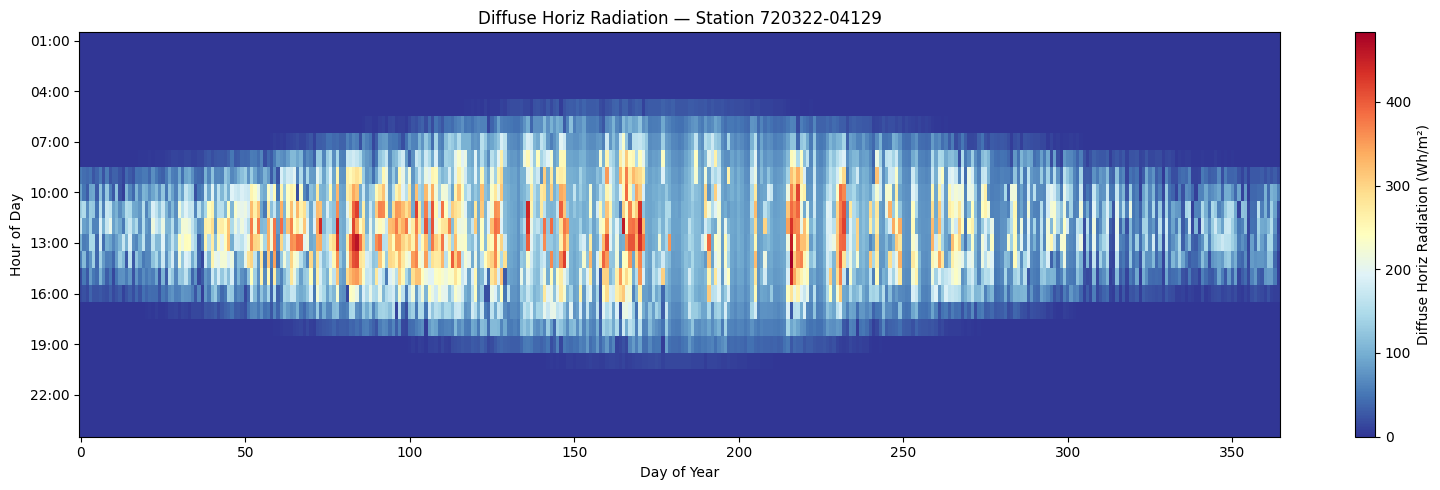

Station : 720322-04129
Component: Diffuse Horiz Radiation
Min: 0.0  Max: 483.0  Mean: 58.8


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Station to inspect — change to any valid station_id
sample_station = pd.Index(valid_station_ids).astype(str)[0]
epw_path = OUT_DIR / f"{sample_station}.epw"

# Component to visualise — change to any name in EPW_DATA_COLS
COMPONENT = "Diffuse Horiz Radiation"

EPW_DATA_COLS = [
    "Year", "Month", "Day", "Hour", "Minute", "Flags",
    "Dry Bulb Temperature", "Dew Point Temperature", "Relative Humidity",
    "Atmospheric Pressure", "ExtraTerr Horiz Radiation", "ExtraTerr Direct Normal Radiation",
    "Horiz IR Radiation Intensity", "Global Horiz Radiation", "Direct Normal Radiation",
    "Diffuse Horiz Radiation", "Global Horiz Illuminance", "Direct Normal Illuminance",
    "Diffuse Horiz Illuminance", "Zenith Luminance", "Wind Direction", "Wind Speed",
    "Total Sky Cover", "Opaque Sky Cover", "Visibility", "Ceiling Height",
    "Present Weather Observation", "Present Weather Codes", "Precipitable Water",
    "Aerosol Optical Depth", "Snow Depth", "Days Since Last Snowfall",
    "Albedo", "Liquid Precipitation Depth", "Liquid Precipitation Quantity",
]

with open(epw_path, encoding="utf-8", errors="replace") as f:
    raw_lines = f.readlines()

rows = []
for line in raw_lines[8:]:  # skip 8 header lines
    parts = line.strip().split(",")
    if len(parts) >= len(EPW_DATA_COLS):
        rows.append(parts[:len(EPW_DATA_COLS)])

df_epw = pd.DataFrame(rows, columns=EPW_DATA_COLS)
for col in ["Year", "Month", "Day", "Hour", COMPONENT]:
    df_epw[col] = pd.to_numeric(df_epw[col], errors="coerce")

df_epw["doy"] = pd.to_datetime(
    df_epw[["Year", "Month", "Day"]].rename(columns={"Year": "year", "Month": "month", "Day": "day"})
).dt.dayofyear

pivot = df_epw.pivot_table(index="Hour", columns="doy", values=COMPONENT, aggfunc="mean")
pivot = pivot.reindex(index=range(1, 25))

unit = "\u00b0C" if "Temperature" in COMPONENT else ("Wh/m\u00b2" if "Radiation" in COMPONENT else "")
label = f"{COMPONENT} ({unit})" if unit else COMPONENT

fig, ax = plt.subplots(figsize=(16, 5))
im = ax.imshow(
    pivot.values,
    aspect="auto",
    origin="upper",
    cmap="RdYlBu_r",
    interpolation="nearest",
)
plt.colorbar(im, ax=ax, label=label)
ax.set_xlabel("Day of Year")
ax.set_ylabel("Hour of Day")
ax.set_title(f"{COMPONENT} — Station {sample_station}")
ax.set_yticks(range(0, 24, 3))
ax.set_yticklabels([f"{h:02d}:00" for h in range(1, 25, 3)])
plt.tight_layout()
plt.show()

vals = pivot.values[~np.isnan(pivot.values)]
print(f"Station : {sample_station}")
print(f"Component: {COMPONENT}")
print(f"Min: {vals.min():.1f}  Max: {vals.max():.1f}  Mean: {vals.mean():.1f}")

## 6a. Patch Ground Temperatures into Generated EPW Files

Replace the empty  header in each AMY EPW with the full ground temperature line extracted from the nearest TMYx source EPW.

In [10]:
HEADERS_TO_PATCH = {"DESIGN CONDITIONS", "TYPICAL/EXTREME PERIODS", "GROUND TEMPERATURES"}
patched, skipped, missing = 0, 0, 0

for station_id, headers in tmyx_header_lines.items():
    epw_path = OUT_DIR / f"{station_id}.epw"
    if not epw_path.exists():
        skipped += 1
        continue

    lines = epw_path.read_text(encoding="utf-8", errors="replace").splitlines(keepends=True)
    new_lines = []
    for line in lines:
        replaced = False
        for prefix, tmy_line in headers.items():
            if line.startswith(prefix):
                new_lines.append(tmy_line.rstrip("\r\n") + "\n")
                replaced = True
                break
        if not replaced:
            new_lines.append(line)
    epw_path.write_text("".join(new_lines), encoding="utf-8")
    patched += 1

for station_id in pd.Index(valid_station_ids).astype(str):
    if station_id not in tmyx_header_lines:
        missing += 1

print(f"Patched {patched} EPW files with TMYx design conditions, typical/extreme periods, and ground temperatures")
if skipped:
    print(f"Skipped {skipped}: EPW not yet generated")
if missing:
    print(f"No TMYx headers available for {missing} station(s)")

Patched 36 EPW files with TMYx design conditions, typical/extreme periods, and ground temperatures


## Package EPW and DDY files per station

Create one ZIP archive per valid station containing the matching `.epw` and `.ddy` files. The summary table flags any stations that are missing either file.

In [11]:
import zipfile

WEATHER_ZIP_DIR = OUT_DIR / "station_weather_zips"
WEATHER_ZIP_DIR.mkdir(parents=True, exist_ok=True)

weather_zip_records = []
for station_id in pd.Index(valid_station_ids).astype(str):
    epw_path = OUT_DIR / f"{station_id}.epw"
    ddy_path = OUT_DIR / f"{station_id}.ddy"
    zip_path = WEATHER_ZIP_DIR / f"{station_id}.zip"

    missing_files = [path.name for path in [epw_path, ddy_path] if not path.exists()]
    if missing_files:
        weather_zip_records.append({
            "station_id": station_id,
            "zip_path": str(zip_path),
            "status": "missing_files",
            "missing_files": ", ".join(missing_files),
        })
        continue

    with zipfile.ZipFile(zip_path, mode="w", compression=zipfile.ZIP_DEFLATED) as zf:
        zf.write(epw_path, arcname=epw_path.name)
        zf.write(ddy_path, arcname=ddy_path.name)

    weather_zip_records.append({
        "station_id": station_id,
        "zip_path": str(zip_path),
        "status": "saved",
        "missing_files": "",
    })

weather_zip_summary = pd.DataFrame(weather_zip_records)
print(f"Saved {weather_zip_summary['status'].eq('saved').sum()} station weather ZIPs to {WEATHER_ZIP_DIR}")
print(weather_zip_summary["status"].value_counts(dropna=False))
display(weather_zip_summary.sort_values(["status", "station_id"]))

Saved 36 station weather ZIPs to ..\src\data\weather\station_weather_zips
status
saved    36
Name: count, dtype: int64


,station_id,zip_path,status,missing_files
0,720322-04129,..\src\data\weather\station_weather_zips\72032...,saved,
1,720734-00264,..\src\data\weather\station_weather_zips\72073...,saved,
2,726810-24131,..\src\data\weather\station_weather_zips\72681...,saved,
3,726813-94195,..\src\data\weather\station_weather_zips\72681...,saved,
4,726836-04201,..\src\data\weather\station_weather_zips\72683...,saved,
5,726881-94273,..\src\data\weather\station_weather_zips\72688...,saved,
6,726920-24230,..\src\data\weather\station_weather_zips\72692...,saved,
7,726930-24221,..\src\data\weather\station_weather_zips\72693...,saved,
8,726945-24202,..\src\data\weather\station_weather_zips\72694...,saved,
9,726959-94281,..\src\data\weather\station_weather_zips\72695...,saved,
